In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib as mpl

# Set high-resolution plots and base font size
mpl.rcParams['figure.dpi'] = 250
mpl.rcParams.update({'font.size': 8})  # Increased for better readability

class RabbitFoxes:
    def __init__(self, a, b, c, d, K, seed=0):
        """
        Initializes the RabbitFoxes simulation with coefficients and carrying capacity.

        Parameters:
        - a (float): Prey (rabbit) growth rate.
        - b (float): Predation rate coefficient.
        - c (float): Predator (fox) death rate.
        - d (float): Predator reproduction rate per prey eaten.
        - K (float): Carrying capacity for the prey population.
        - seed (int): Random seed for reproducibility.
        """
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.K = K
        self.seed = seed
        np.random.seed(self.seed)

        # Define color themes
        self.main_colors = {
            'background': '#ffffff',      # White background
            'vector_field': '#FF8C00',    # Dark Orange
            'trajectory': '#800080',      # Purple
            'init_point': '#FF4500',      # OrangeRed
            'color_map': 'plasma',        # Plasma colormap has orange and purple hues
        }

        # Apply a built-in Matplotlib style and customize colors
        plt.style.use('default')  # Use 'default' to avoid Seaborn dependency
        mpl.rcParams.update({
            'axes.facecolor': self.main_colors['background'],
            'axes.edgecolor': 'black',
            'axes.labelcolor': 'black',
            'text.color': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'figure.facecolor': self.main_colors['background'],
            'grid.color': '#cccccc',
            'grid.linestyle': '--',
            'grid.linewidth': 0.5,
        })

    def lotka_volterra(self, state, t):
        """
        Defines the Lotka-Volterra equations with logistic growth for prey.

        Parameters:
        - state (list): Current state [prey, predator].
        - t (float): Current time (unused, but required by odeint).

        Returns:
        - list: Derivatives [dprey_dt, dpredator_dt].
        """
        prey, predator = state
        dprey_dt = self.a * prey * (1 - prey / self.K) - self.b * prey * predator
        dpredator_dt = self.d * prey * predator - self.c * predator
        return [dprey_dt, dpredator_dt]

    def solve_ode(self, t, initial_conditions=None):
        """
        Solves the Lotka-Volterra ODEs over time t for given initial conditions.

        Parameters:
        - t (array): Array of time points.
        - initial_conditions (array, optional): Array of initial states [prey, predator].
                                                 If None, uses default initial conditions.

        Returns:
        - array: Solution array with shape (len(t), 2).
        """
        if initial_conditions is None:
            # Default initial conditions
            initial_conditions = [10, 5]  # Example: 10 rabbits and 5 foxes
        solution = odeint(self.lotka_volterra, initial_conditions, t)
        return solution

    def generate_uniform_initial_conditions(self, num_points, prey_range, predator_range):
        """
        Generates uniformly distributed initial conditions for multiple simulations.

        Parameters:
        - num_points (int): Number of initial conditions to generate.
        - prey_range (tuple): (min, max) range for prey population.
        - predator_range (tuple): (min, max) range for predator population.

        Returns:
        - array: Array of initial conditions with shape (num_points, 2).
        """
        prey_init = np.random.uniform(prey_range[0], prey_range[1], num_points)
        predator_init = np.random.uniform(predator_range[0], predator_range[1], num_points)
        # Ensure prey does not exceed carrying capacity
        prey_init = np.clip(prey_init, 0.1, self.K)
        predator_init = np.clip(predator_init, 0.1, None)  # Prevent zero predators
        initial_conditions = np.vstack((prey_init, predator_init)).T
        return initial_conditions

    def plot_phase_space(self, t, solutions, ax):
        """
        Plots the phase space (prey vs. predator) with trajectories colored by time.

        Parameters:
        - t (array): Array of time points.
        - solutions (list of arrays): List of solution arrays from ODE solver.
        - ax (matplotlib.axes.Axes): Axes object to plot on.
        """
        cmap = self.main_colors['color_map']
        norm = plt.Normalize(t.min(), t.max())

        for solution in solutions:
            x = solution[:, 0]
            y = solution[:, 1]

            # Create segments for LineCollection
            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Create LineCollection
            lc = LineCollection(segments, cmap=cmap, norm=norm)
            lc.set_array(t)
            lc.set_linewidth(2)
            line = ax.add_collection(lc)

            # Scatter initial point
            ax.scatter(x[0], y[0], color=self.main_colors['init_point'], zorder=5)

        # Set limits based on all solutions
        all_x = np.concatenate([sol[:, 0] for sol in solutions])
        all_y = np.concatenate([sol[:, 1] for sol in solutions])
        ax.set_xlim(all_x.min() * 0.9, all_x.max() * 1.1)
        ax.set_ylim(all_y.min() * 0.9, all_y.max() * 1.1)

        # Labels and title
        ax.set_xlabel('Rabbits')
        ax.set_ylabel('Foxes')
        ax.set_title('Phase Space Trajectories')

        # Add a single colorbar for all trajectories
        cbar = plt.colorbar(line, ax=ax, label='Time', pad=0.02)
        cbar.ax.tick_params(labelsize=6)

    def plot_vector_field(self, ax, prey_range, predator_range, num_pts=20):
        """
        Plots the vector field for the Lotka-Volterra system.

        Parameters:
        - ax (matplotlib.axes.Axes): Axes object to plot on.
        - prey_range (tuple): (min, max) range for prey population.
        - predator_range (tuple): (min, max) range for predator population.
        - num_pts (int): Number of points in each dimension.
        """
        X, Y = np.meshgrid(np.linspace(*prey_range, num_pts), np.linspace(*predator_range, num_pts))
        U = self.a * X * (1 - X / self.K) - self.b * X * Y
        V = self.d * X * Y - self.c * Y

        # Normalize vectors for better visualization
        magnitude = np.sqrt(U**2 + V**2)
        magnitude[magnitude == 0] = 1  # Prevent division by zero
        U_norm = U / magnitude
        V_norm = V / magnitude

        # Adjust the scale to control arrow length
        ax.quiver(X, Y, U_norm, V_norm, color=self.main_colors['vector_field'],
                  alpha=0.6, pivot='mid', scale=30, width=0.005)

        ax.set_title('Vector Field')

    def plot_derivative_colored(self, t, solutions, ax):
        """
        Plots trajectories colored by the magnitude of their derivatives.

        Parameters:
        - t (array): Array of time points.
        - solutions (list of arrays): List of solution arrays from ODE solver.
        - ax (matplotlib.axes.Axes): Axes object to plot on.
        """
        cmap = self.main_colors['color_map']

        for solution in solutions:
            x = solution[:, 0]
            y = solution[:, 1]

            # Calculate derivatives
            dx = self.a * x * (1 - x / self.K) - self.b * x * y
            dy = self.d * x * y - self.c * y
            deriv_magnitude = np.sqrt(dx**2 + dy**2)

            # Normalize derivative magnitude for colormap
            norm = plt.Normalize(deriv_magnitude.min(), deriv_magnitude.max())

            # Create segments for LineCollection
            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Create LineCollection
            lc = LineCollection(segments, cmap=cmap, norm=norm)
            lc.set_array(deriv_magnitude)
            lc.set_linewidth(2)
            line = ax.add_collection(lc)

            # Scatter initial point
            ax.scatter(x[0], y[0], color=self.main_colors['init_point'], zorder=5)

        # Set limits based on all solutions
        all_x = np.concatenate([sol[:, 0] for sol in solutions])
        all_y = np.concatenate([sol[:, 1] for sol in solutions])
        ax.set_xlim(all_x.min() * 0.9, all_x.max() * 1.1)
        ax.set_ylim(all_y.min() * 0.9, all_y.max() * 1.1)

        # Labels and title
        ax.set_xlabel('Rabbits')
        ax.set_ylabel('Foxes')
        ax.set_title('Trajectories Colored by Derivative Magnitude')

        # Add a single colorbar for all trajectories
        cbar = plt.colorbar(line, ax=ax, label='Derivative Magnitude', pad=0.02)
        cbar.ax.tick_params(labelsize=6)

    def plot_time_series(self, t, solutions, ax1, ax2):
        """
        Plots the time series for prey and predator populations and their derivatives.

        Parameters:
        - t (array): Array of time points.
        - solutions (list of arrays): List of solution arrays from ODE solver.
        - ax1 (matplotlib.axes.Axes): Axes object for population plots.
        - ax2 (matplotlib.axes.Axes): Axes object for derivative plots.
        """
        cmap = self.main_colors['color_map']
        colors = plt.cm.plasma(np.linspace(0, 1, len(solutions)))

        for idx, solution in enumerate(solutions):
            x = solution[:, 0]
            y = solution[:, 1]

            # Calculate derivatives
            dx = self.a * x * (1 - x / self.K) - self.b * x * y
            dy = self.d * x * y - self.c * y

            # Plot populations
            ax1.plot(t, x, color=colors[idx], label=f'Rabbits Traj {idx+1}')
            ax1.plot(t, y, '--', color=colors[idx], label=f'Foxes Traj {idx+1}')

            # Plot derivatives
            ax2.plot(t, dx, color=colors[idx], label=f"Rabbits' Derivative {idx+1}")
            ax2.plot(t, dy, '--', color=colors[idx], label=f"Foxes' Derivative {idx+1}")

        # Labels and titles
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Population')
        ax1.set_title('Population Over Time')
        ax1.legend(fontsize=6, loc='upper right')

        ax2.set_xlabel('Time')
        ax2.set_ylabel('Derivative')
        ax2.set_title('Derivative Over Time')
        ax2.legend(fontsize=6, loc='upper right')

    def plot_all(self, t, solutions):
        """
        Generates all plots: Phase Space, Vector Field, Derivative-Colored Trajectories, and Time Series.

        Parameters:
        - t (array): Array of time points.
        - solutions (list of arrays): List of solution arrays from ODE solver.
        """
        # Create a figure with 1x3 subplots for phase space, vector field, and derivative-colored trajectories
        fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
        traj_ax, vecfield_ax, deriv_color_ax = axes

        # Plot Phase Space Trajectories
        self.plot_phase_space(t, solutions, traj_ax)

        # Determine ranges from all solutions for vector field
        all_x = np.concatenate([sol[:, 0] for sol in solutions])
        all_y = np.concatenate([sol[:, 1] for sol in solutions])
        prey_min, prey_max = all_x.min() * 0.9, all_x.max() * 1.1
        predator_min, predator_max = all_y.min() * 0.9, all_y.max() * 1.1

        # Plot Vector Field
        self.plot_vector_field(vecfield_ax, [prey_min, prey_max], [predator_min, predator_max])

        # Plot Derivative-Colored Trajectories
        self.plot_derivative_colored(t, solutions, deriv_color_ax)

        plt.show()

        # Create a separate figure for Time Series plots
        fig_ts, axes_ts = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
        ax1, ax2 = axes_ts
        self.plot_time_series(t, solutions, ax1, ax2)
        plt.show()

    def run_simulation(self, max_t=15, num_points=1000, num_initial_conditions=1,
                       prey_range=(1, 20), predator_range=(1, 20)):
        """
        Runs the simulation by solving the ODEs for multiple initial conditions and plotting the results.

        Parameters:
        - max_t (float): Maximum time for the simulation.
        - num_points (int): Number of time points.
        - num_initial_conditions (int): Number of initial conditions to simulate.
        - prey_range (tuple): (min, max) range for prey population in initial conditions.
        - predator_range (tuple): (min, max) range for predator population in initial conditions.
        """
        t = np.linspace(0, max_t, num_points)

        # Generate initial conditions
        initial_conditions = self.generate_uniform_initial_conditions(num_initial_conditions,
                                                                        prey_range, predator_range)

        # Solve ODE for each initial condition
        solutions = []
        for init_cond in initial_conditions:
            solution = self.solve_ode(t, initial_conditions=init_cond)
            solutions.append(solution)

        # Plot all results
        self.plot_all(t, solutions)


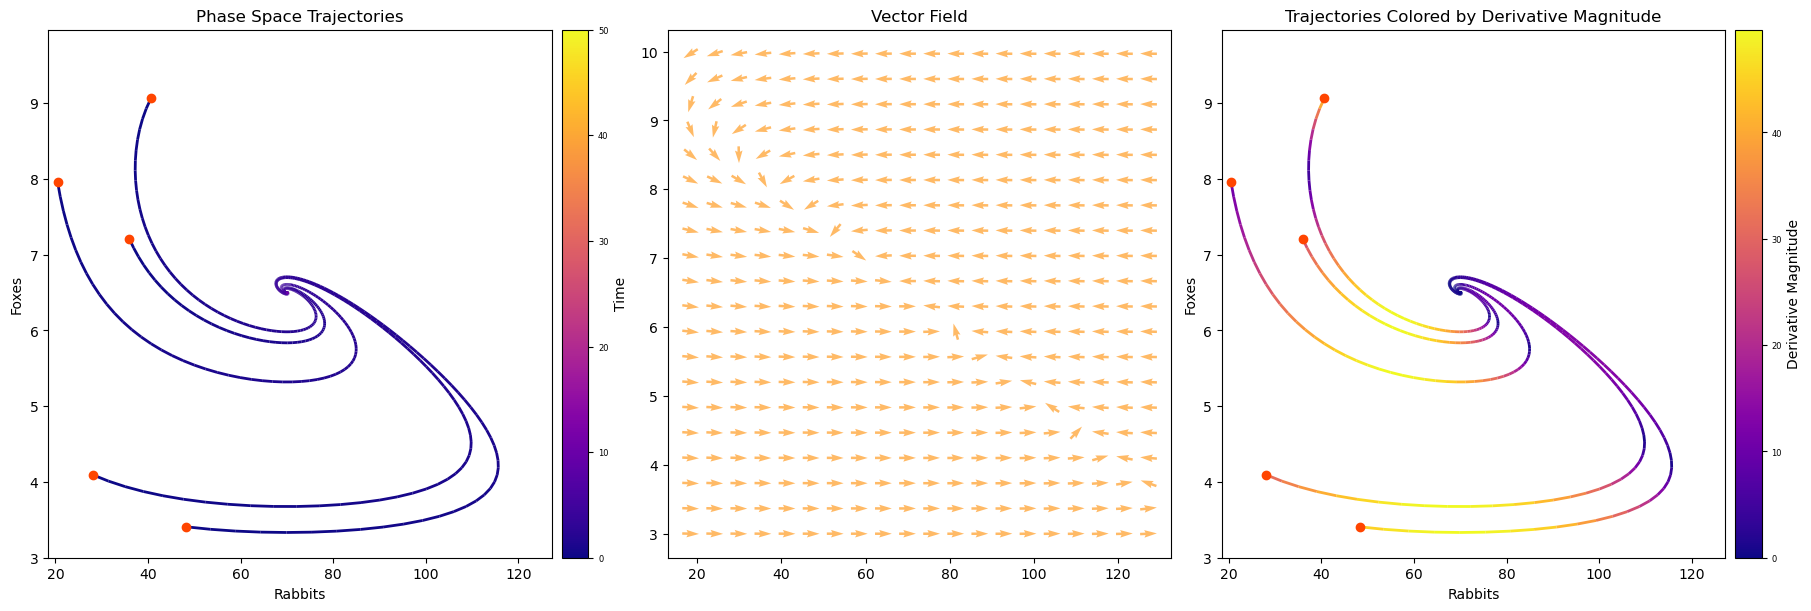

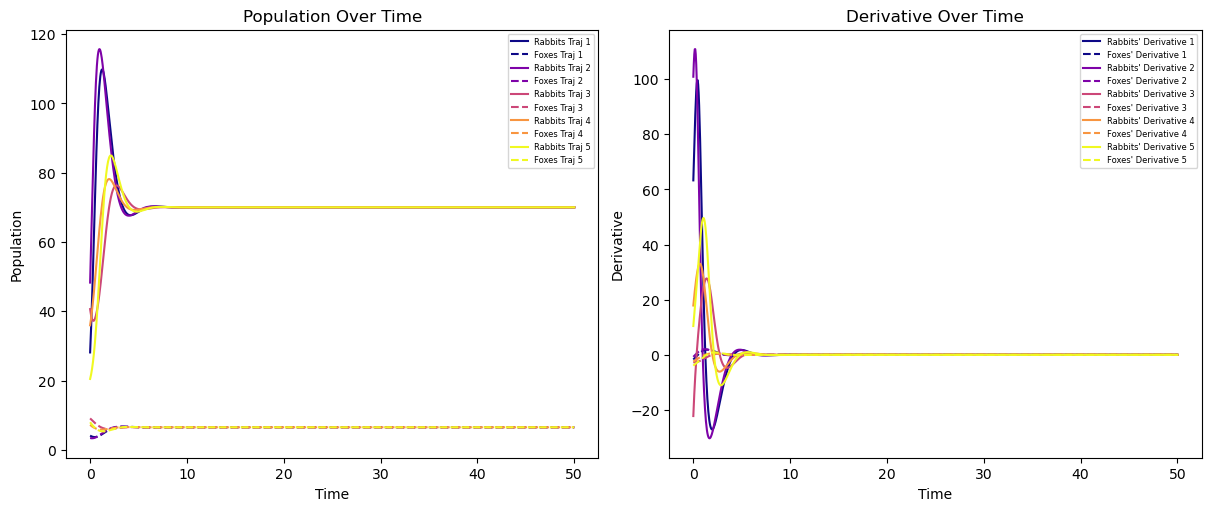

In [5]:
# Define coefficients and carrying capacity
a = 5.0               # Prey growth rate
b = 0.5               # Predation rate coefficient
c = 0.7               # Predator death rate
d = 0.01              # Predator reproduction rate per prey eaten
K = 200        # Carrying capacity for rabbits

# Create an instance of RabbitFoxes
rf = RabbitFoxes(a=a, b=b, c=c, d=d, K=K, seed=42)

# Run the simulation
rf.run_simulation(
    max_t=50,                       # Maximum time
    num_points=1000,                # Number of time points
    num_initial_conditions=5,       # Number of uniform initial conditions to generate
    prey_range=(15, 50),             # Prey population range for initial conditions
    predator_range=(3, 10)          # Predator population range for initial conditions
)